<a href="https://colab.research.google.com/github/LoraShima/Exercises_CV_2026/blob/main/Exercise2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 2

**Before starting:**

- Create a GitHub repository to upload the solution of this exercise.
- Share this GitHub link to your professor.

**Objectives**

Generate a single Python notebook implementing and answering the following questions:

🔹 **Task 1:** Load an image and apply a thresholding method. Analyze and discuss the segmentation results.


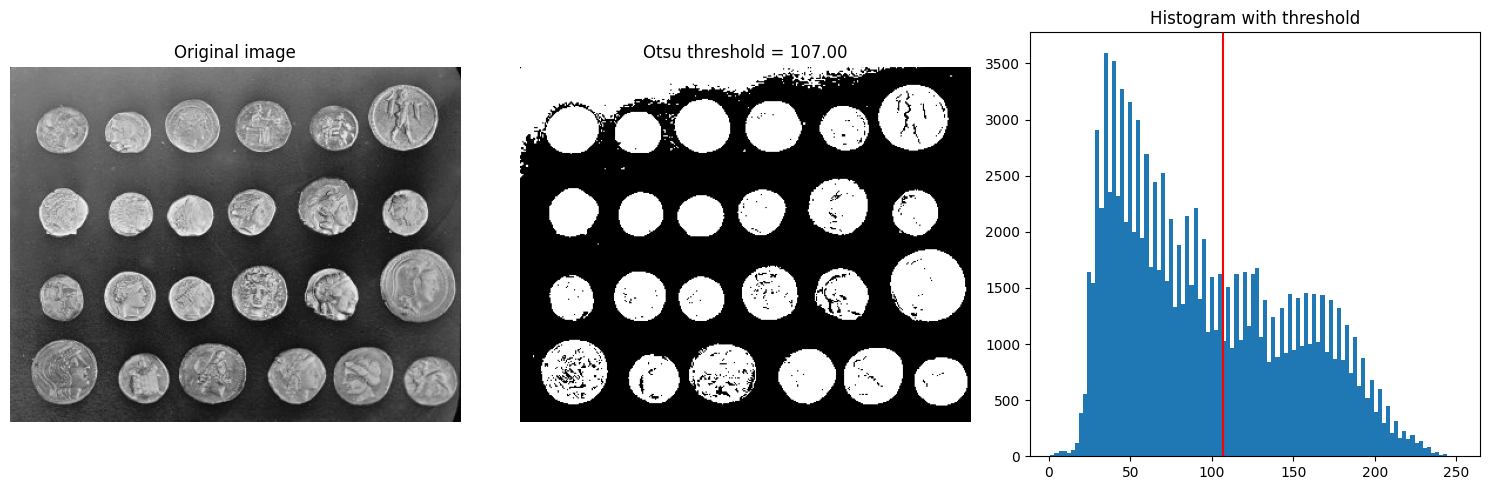

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from skimage.filters import threshold_otsu
from skimage.color import rgb2gray

image = data.coins()

thresh = threshold_otsu(image)
binary = image > thresh

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
images = [image, binary, image]
titles = ['Original image', f'Otsu threshold = {thresh:.2f}', 'Histogram']

for i in range(2):
    axes[i].imshow(images[i], cmap='gray')
    axes[i].set_title(titles[i])
    axes[i].axis('off')

axes[2].hist(image.ravel(), bins=100)
axes[2].axvline(thresh, color='r')
axes[2].set_title('Histogram with threshold')

plt.tight_layout()
plt.show()

**Comment**: The results show that Otsu thresholding successfully separates the bright coin regions from the darker background by automatically selecting an optimal intensity threshold of approximately 107. In the segmented image, most of the coins appear as white objects while the background becomes black, demonstrating that the method works well when there is a clear intensity difference between foreground and background. The histogram helps explain this behavior: the red vertical line represents the chosen threshold value that divides darker pixels from brighter pixels. However, some small dark holes and imperfections remain inside the coins because not all coin pixels have uniform brightness, and some background variations are still present.


🔹 **Task 2:** Load an image and apply an unsupervised segmentation method (e.g., K-Means). Evaluate and comment on the outcome.


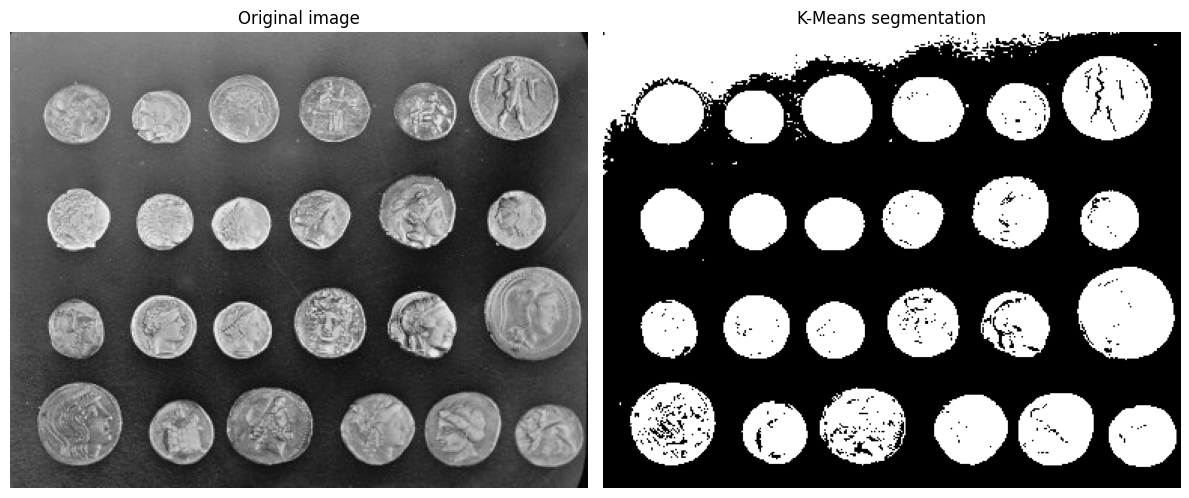

In [2]:
from sklearn.cluster import KMeans

image = data.coins()

# Reshape image into N x d array
v_image = image.reshape(image.shape[0] * image.shape[1], 1)

# Apply K-Means clustering
n_clusters = 2
kmeans = KMeans(n_clusters=n_clusters, random_state=0)

labels = kmeans.fit_predict(v_image)

# Reshape back as image
segmented = labels.reshape(image.shape[0], image.shape[1])

# Display results
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

images = [image, segmented]
titles = ['Original image', 'K-Means segmentation']

for i in range(2):

    axes[i].imshow(images[i], cmap='gray')
    axes[i].set_title(titles[i])
    axes[i].axis('off')

plt.tight_layout()
plt.show()

**Comment**: The K-Means algorithm performs unsupervised segmentation by grouping pixels according to similarity in their intensity values without using labeled data. In this example, the algorithm separates the image into two clusters that approximately correspond to the bright coin regions and the darker background. The segmentation result is relatively effective because the coins and background have different intensity distributions. However, some pixels may still be incorrectly grouped due to shadows, illumination variations, or texture differences inside the coins. Unlike thresholding, K-Means does not directly use a single threshold value, but instead iteratively groups pixels around cluster centroids based on similarity.

🔹 **Task 3:** Load an image and apply a supervised segmentation method (e.g., with annotated labels or using a classifier). Discuss the effectiveness and limitations.

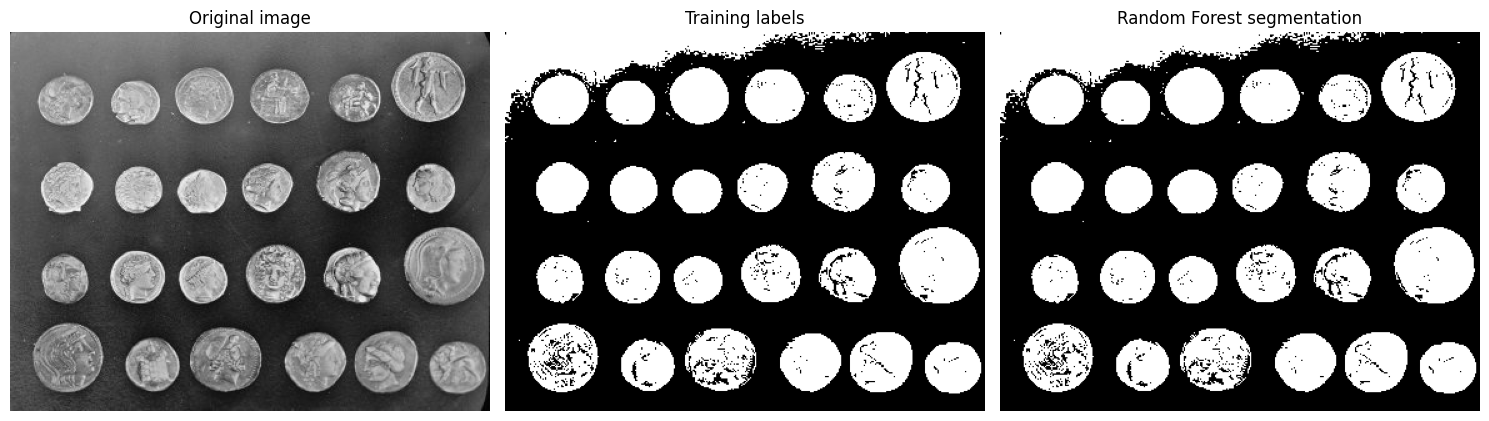

In [5]:
from sklearn.ensemble import RandomForestClassifier

# Load image
image = data.coins()

# Create labels automatically using thresholding
labels = image > 110

# Convert image and labels to 1D format
image_2D = image.reshape((-1, 1))
labels_1D = labels.reshape(-1)

# Train Random Forest classifier
classifier = RandomForestClassifier(random_state=0)
classifier.fit(image_2D, labels_1D)

# Predict segmentation for all pixels
predicted = classifier.predict(image_2D)
segmented = predicted.reshape(image.shape)

# Display results
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

images = [image, labels, segmented]
titles = ['Original image', 'Training labels', 'Random Forest segmentation']

for i in range(3):
    axes[i].imshow(images[i], cmap='gray')
    axes[i].set_title(titles[i])
    axes[i].axis('off')

plt.tight_layout()
plt.show()

**Comment**: The segmentation result is relatively effective because most of the coin regions are clearly separated from the darker background. The detected objects preserve the general shapes of the coins and the boundaries are well identified in most areas. Some small imperfections and noisy regions are still visible, especially inside textured coins where intensity variations are stronger.

🔹 **Task 4:** Explain the main differences between supervised and unsupervised segmentation approaches. Discuss their advantages and disadvantages, and illustrate your explanation with an example.

Supervised and unsupervised segmentation are two different approaches used to separate regions or objects in an image. In supervised segmentation, the algorithm learns from labeled training data, meaning that example pixels or regions are already identified as belonging to specific classes such as object or background. The model then uses this information to classify the remaining pixels in new images. In contrast, unsupervised segmentation does not require labeled data. Instead, the algorithm automatically groups pixels according to similarities such as intensity, color, or texture.

The main advantage of supervised segmentation is that it can achieve high accuracy because the model learns the characteristics of the target classes from annotated examples. Methods such as Random Forest, LDA, or Gaussian Naive Bayes can adapt to complex patterns and provide meaningful segmentation results when representative training data is available. However, supervised approaches require manually labeled ground truth images, which can be time-consuming and expensive to create. Their performance also strongly depends on the quality of the training labels and the chosen features.

Unsupervised segmentation methods, such as K-Means clustering or thresholding, are simpler because they do not require labeled data. They are fast and easy to apply to new images, making them useful when annotations are unavailable. However, they only group pixels according to similarity and do not truly “understand” the objects in the image. As a result, the segmented regions may not always correspond to meaningful structures, especially in images with shadows, noise, or complex textures.

For example, in the coins image, K-Means segmentation can separate many bright coin regions from the darker background by clustering similar intensity values. However, some regions may still be incorrectly grouped due to illumination variations. In supervised segmentation, a classifier trained with labeled examples of coin and background pixels can learn the characteristics of both classes and usually produce more accurate object separation. This illustrates how supervised methods generally provide better control and precision, while unsupervised methods are simpler and require less preparation.
